# An analysis of the produce and price volatility of principal Canadian crops

## Introduction

We have been hired as a data analyst by a US venture capital company, which has recently invested into the microbrewery and microdistillery industry. Our task is to perform a high-level analysis of crop production in Canada in order to inform our employer’s supply chain decisions. We therefore need to help the stakeholders understand the supply and price volatility of select crop types.

## Summary

[SUMMARY HERE]

## Report

### Report introduction

We are given [Canadian principal crops data](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMRP0203ENSkillsNetwork23863830-2021-01-01&pid=3210035901) (1908-2020) listing the measures of pricipal crop produce subsettable by province or territory, [farm product prices](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMRP0203ENSkillsNetwork23863830-2021-01-01&pid=3210007701) (1980-2020) listing the average prices of farm produce and [Bank of Canada daily average exchange rates](https://www.bankofcanada.ca/rates/exchange/daily-exchange-rates?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMRP0203ENSkillsNetwork23863830-2021-01-01).

### Toolbox

The analysis below utilises the R programming language and the tidyverse library in processing and plotting the data. To obtain the data, we create a database and retrieve data with the SQLite dialect of SQL and the relevant libries allowing us to import the data into the R environment.

In [205]:
# Libraries
library(tidyverse)
library(RSQLite)
library(DBI)

## Workings

### Helpers

In [206]:
# SQL tab constructor
construct_tab <- function(channel, construction_query) {
    c <- channel
    q <- construction_query

    # Execute channel-query
    df <- tryCatch(
        dbExecute(c, q),
        error = function(e) e
    )

    # Check whether df is an error object
    if (inherits(df, "error")) {
        cat("An error has occurred.\n")
        print(df$message)
    } else {
        cat("Table has been created successfully.\n")
    }
}

# Set up Jupyter graph display
options(
  repr.plot.width  = 10,
  repr.plot.height = 6,
  repr.plot.res    = 150
)

### Construct the database and load up the data

In [207]:
# Annual Crop Data
acd_path <- r"(https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-RP0203EN-SkillsNetwork/labs/Final%20Project/Annual_Crop_Data.csv)"

# Farm product prices
fpp_path <- r"(https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-RP0203EN-SkillsNetwork/labs/Final%20Project/Monthly_Farm_Prices.csv)"

# Daily FX Data
dfx_path <- r"(https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-RP0203EN-SkillsNetwork/labs/Final%20Project/Daily_FX.csv)"

# Monthly FX Data
mfx_path <- r"(https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-RP0203EN-SkillsNetwork/labs/Final%20Project/Monthly_FX.csv)"

In [208]:
# Establish an RSQLite connection
c <- dbConnect(SQLite(), "data/FinalDB_final_project.sqlite")

In [209]:
# Drop the tabs if they already exist
tab_vec <- c("crop_data", "prod_prices", "daily_fx", "monthly_fx")

for (tab in tab_vec) {
    q <- sprintf("
    DROP TABLE IF EXISTS %s;
    ", tab)
    dbExecute(c, q)
}

In [210]:
# Load the csvs into a list of data frames
path_vec <- c(acd_path, fpp_path, dfx_path, mfx_path)
name_vec <- c("acd_path", "fpp_path", "dfx_path", "mfx_path")
path_dic <- setNames(path_vec, name_vec)

data_list <- list()

for (path_name in names(path_dic)) {
    # Load up the dataset and clean the column names
    ds <- read_csv(
        path_dic[[path_name]],
        show_col_types = FALSE
    ) |> janitor::clean_names()
    
    # Add the df into the list
    data_list[[path_name]] <- ds

    # Obtain the column names for tab construction
    cat(path_name, "columns:\n", colnames(data_list[[path_name]]), "\n\n")
    # Obtain the data types
    #cat("Structure":\n", str(data_list[[path_name]]), "\n\n")
}

acd_path columns:
 cd_id year crop_type geo seeded_area harvested_area production avg_yield 

fpp_path columns:
 cd_id date crop_type geo price_prermt 

dfx_path columns:
 dfx_id date fxusdcad 

mfx_path columns:
 dfx_id date fxusdcad 



In [211]:
# Construct the tabs
construction_queries <- c(
    "
    CREATE TABLE IF NOT EXISTS crop_data (
        cd_id INTEGER NOT NULL,
        year DATE NOT NULL,
        crop_type VARCHAR(20) NOT NULL,
        geo VARCHAR(20) NOT NULL,
        seeded_area INTEGER NOT NULL,
        harvested_area INTEGER NOT NULL,
        production INTEGER NOT NULL,
        avg_yield INTEGER NOT NULL,
        PRIMARY KEY(cd_id)
    );
    ",
    "
    CREATE TABLE IF NOT EXISTS prod_prices (
        cd_id INTEGER NOT NULL,
        date DATE NOT NULL,
        crop_type VARCHAR(20) NOT NULL,
        geo VARCHAR(20) NOT NULL,
        price_prermt INTEGER NOT NULL,
        PRIMARY KEY (cd_id)
    );
    ",
    "
    CREATE TABLE IF NOT EXISTS daily_fx (
        dfx_id INTEGER NOT NULL,
        date DATE NOT NULL,
        fxusdcad FLOAT(6) NOT NULL,
        PRIMARY KEY(dfx_id)
    );
    ",
    "
    CREATE TABLE IF NOT EXISTS montly_fx (
        dfx_id INTEGER NOT NULL,
        date DATE NOT NULL,
        fxusdcad FLOAT(6) NOT NULL,
        PRIMARY KEY(dfx_id)
    );
    "
)
construction_dic <- setNames(construction_queries, tab_vec)

for (tab in names(construction_dic)) {
    q <- construction_dic[[tab]]
    construct_tab(c, q)
}

Table has been created successfully.
Table has been created successfully.
Table has been created successfully.
Table has been created successfully.


In [212]:
# List tabs
dbListTables(c)

[1] "crop_data"   "daily_fx"    "montly_fx"   "prod_prices"

In [213]:
# Load up SQLite database
for (i in seq_along(data_list)) {
    # Tab name
    tab_name <- tab_vec[i]
    # Write the tab into the database
    dbWriteTable(c, tab_name, data_list[[i]], overwrite = FALSE, append = TRUE, header = TRUE)
    # Retrieve the row count
    row_count <- dbGetQuery(c, sprintf("SELECT COUNT(*) FROM %s", tab_name)) |> pull()
    
    cat("Rows in", tab_name, ":", row_count, "\n")
}

Rows in crop_data : 672 
Rows in prod_prices : 2678 
Rows in daily_fx : 1033 
Rows in monthly_fx : 50 


In [214]:
# Clear the memory
rm(data_list)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1967045,105.1,3033185,162,3033185,162
Vcells,3658703,28.0,8388608,64,7204160,55


### DB queries

In [215]:
# Format the dates
for (tab in tab_vec) {
    fields <- dbListFields(c, tab)

    if ("year" %in% fields) {
        date_col <- "year"
    } else {
        date_col <- "date"
    }

    # Rename the original date column
    q <- sprintf("
    ALTER TABLE %s RENAME COLUMN %s TO days_int;
    ", tab, date_col)
    dbExecute(c, q)

    # Add a column for date strings
    q <- sprintf("
    ALTER TABLE %s ADD COLUMN days_str TEXT;
    ", tab)
    dbExecute(c, q)

    # Add a column for the formatted date
    q <- sprintf("
    ALTER TABLE %s ADD COLUMN %s TEXT;
    ", tab, date_col)
    dbExecute(c, q)

    # Convert the number into a date-ready string
    # `||` SQL string concatenation operator; msql: CONCAT('hello', ' world')
    q <- sprintf("
    UPDATE %s
    SET days_str = CAST(days_int AS INTEGER) || ' days';
    ", tab)
    dbExecute(c, q)

    # Construct the date
    q <- sprintf("
    UPDATE %s
    SET %s = DATE('1970-01-01', days_str);
    ", tab, date_col)
    dbExecute(c, q)

    # Drop the helper cols
    q <- sprintf("
    ALTER TABLE %s
    DROP days_int;
    ", tab)
    dbExecute(c, q)

    q <- sprintf("
    ALTER TABLE %s
    DROP days_str;
    ", tab)
    dbExecute(c, q)
}

In [230]:
# Geographies in the crop and farm prices datasets
q <- "
SELECT DISTINCT(geo) FROM crop_data
WHERE geo NOT IN ('Canada');
"
dbGetQuery(c, q)

geo
<chr>
Alberta
Saskatchewan


In [217]:
# Which geographies are included in the farm prices dataset?
q <- "
SELECT DISTINCT(geo) FROM prod_prices;
"
dbGetQuery(c, q)

geo
<chr>
Alberta
Saskatchewan


Our datasets feature prices for two unique geographies alone. This may potentially have an impact on our decision if we are interested in diversifying risk.

In [ ]:
# Look at the history of crops harvested in the whole of Canada
q <- "
SELECT
    year,
    crop_type,
    seeded_area,
    harvested_area,
    (harvested_area * 1.0 / seeded_area) AS harvested_planted_ratio,
    (seeded_area - harvested_area) * 1.0 / seeded_area AS percentage_abandoned
FROM crop_data
WHERE 
    LOWER(crop_type) IN ('canola', 'barley', 'rye') AND 
    STRFTIME('%Y', year) >= '1960' AND
    geo = 'Canada';
"
crops_of_interest_ts1 <- dbGetQuery(c, q)
crops_of_interest_ts1 |> 
    filter(harvested_planted_ratio != 1) |>
    head()

,year,crop_type,seeded_area,harvested_area,harvested_planted_ratio,percentage_abandoned
,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>
1,1973-12-31,Barley,4936800,4835800,0.9795414,0.02045860
2,1974-12-31,Barley,4851700,4769150,0.9829853,0.01701465
3,1975-12-31,Barley,4586450,4462450,0.9729638,0.02703616
4,1976-12-31,Barley,4475450,4352950,0.9726285,0.02737155
5,1977-12-31,Barley,4873600,4752600,0.9751724,0.02482764
6,1978-12-31,Barley,4392500,4266500,0.9713147,0.02868526


Note that the seeded and the harvested area is given in hectares.

In [240]:
# Pivot the df for plotting
crops_of_interest_ts1_long <- crops_of_interest_ts1 |>
    pivot_longer(
        cols = -c(crop_type, year),
        names_to = "var",
        values_to = "val"
    )

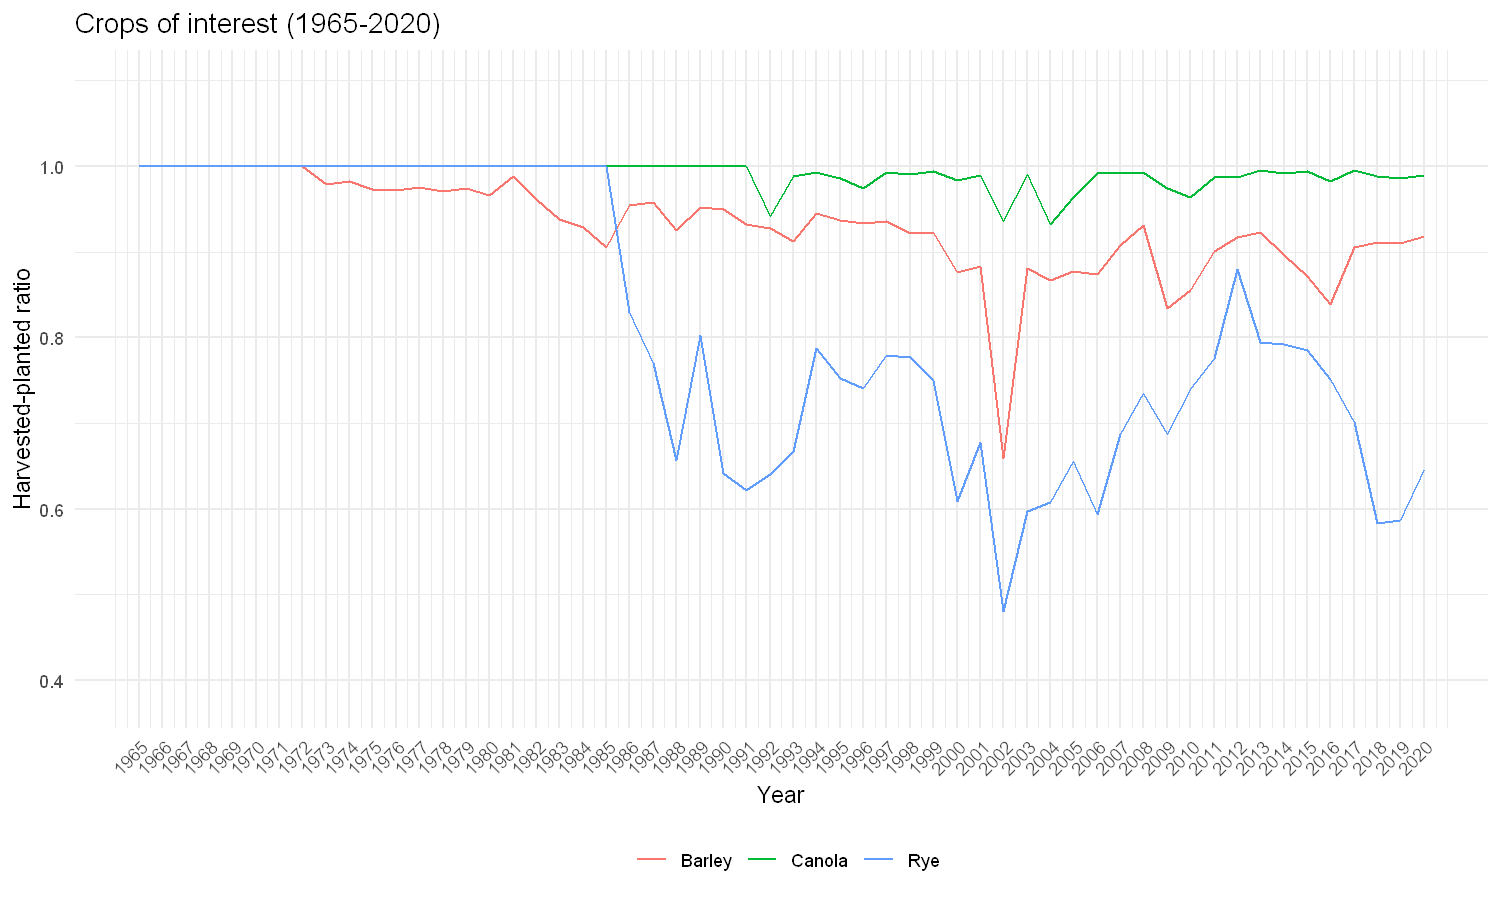

In [ ]:
# Plot the harvested-planted ratio
df <- crops_of_interest_ts1_long |> 
    filter(var == "harvested_planted_ratio") |>
    mutate(year = year(year))

ggplot(
    data = df,
    mapping = aes(x = year, y = val, colour = crop_type, group = crop_type)
) + 
    geom_line() + 
    labs(
        title = paste0("Crops of interest (", min(df$year), "-", max(df$year), ")"),
        x = "Year",
        y = "Harvested-planted ratio",
        colour = ""
    ) + 
    scale_y_continuous(
        limits = c(
            min(df$val) - 0.1, 
            max(df$val) + 0.1
            )
    ) + 
    scale_x_continuous(
        breaks = seq(min(df$year), max(df$year), 1)
    ) +
    theme_minimal() +
    theme(
        legend.position = "bottom",
        legend.direction = "horizontal"
    ) +
    guides(color = guide_legend(nrow = 1)) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))

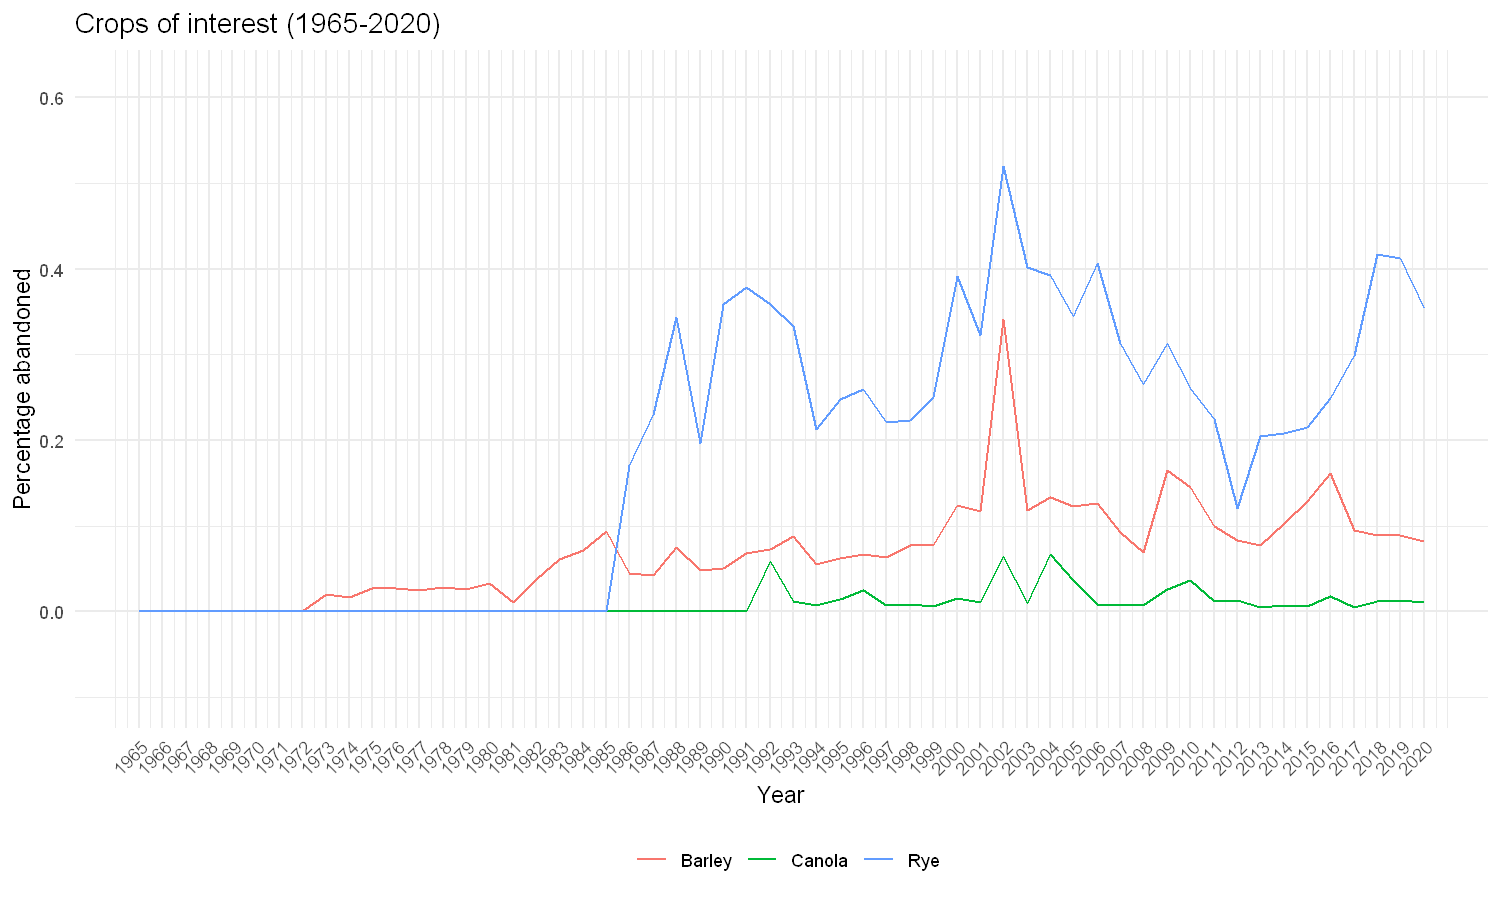

In [ ]:
# Plot the percentage abandoned
df <- crops_of_interest_ts1_long |> 
    filter(var == "percentage_abandoned") |>
    mutate(year = year(year))

ggplot(
    data = df,
    mapping = aes(x = year, y = val, colour = crop_type, group = crop_type)
) + 
    geom_line() + 
    labs(
        title = paste0("Crops of interest (", min(df$year), "-", max(df$year), ")"),
        x = "Year",
        y = "Percentage abandoned",
        colour = ""
    ) + 
    scale_y_continuous(
        limits = c(
            min(df$val) - 0.1, 
            max(df$val) + 0.1
            )
    ) + 
    scale_x_continuous(
        breaks = seq(min(df$year), max(df$year), 1)
    ) +
    theme_minimal() +
    theme(
        legend.position = "bottom",
        legend.direction = "horizontal"
    ) +
    guides(color = guide_legend(nrow = 1)) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))

We can see that relatively little canola goes to waste, whereas substantial amounts of rye go unharvested. we may hazard a speculation that this is either due to a crop disease, rot, some inherent crop failure pattern or maybe a market glut and an excessively low price. We have not collected the weather data, but the datasets allow us to look at a naive relationship between the percentage abandoned and price. Assuming the laws of supply and demand hold, we may be able to rule out market glut as a cause.

There seems to be a noteworthy coincidence between the areas seeded and harvested in the barley data up to 1985 and in the canola data up to 1991.

In [ ]:
# Look at the average prices


In [ ]:
# Look at the naive price-pc abandoned relationship


In [ ]:
# Look at the crop prices in USD and CAD


In [229]:
# Disconnect
#dbDisconnect(c)